# Task 1 — Maternal Risk Classifier: EDA & Model

Predicts a mother's risk level (`low risk` / `mid risk` / `high risk`) from six routine clinical measurements, using the [UCI Maternal Health Risk](https://archive.ics.uci.edu/dataset/863/maternal+health+risk) dataset.

This notebook documents the exploratory data analysis and reproduces the model training done in `src/task1_risk_classifier.py` (imported directly here so there is a single source of truth for the modelling logic — this notebook is the narrative/EDA layer on top of it).

**Before running:** from the `project7-maternal-child-health/` directory, run `python scripts/download_data.py` once to populate `data/raw/maternal_health_risk.csv` (not committed to the repo).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from task1_risk_classifier import FEATURES, TARGET, load_data, train  # noqa: E402

sns.set_theme(style="whitegrid")
RISK_ORDER = ["low risk", "mid risk", "high risk"]

## 1. Load data

In [2]:
df = load_data()
print(f"Shape: {df.shape}")
df.head()

Shape: (1014, 7)


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


## 2. Data quality checks

Check for missing values and duplicate rows before trusting any downstream stats — the UCI Maternal Health Risk dataset is known to contain duplicate readings.

In [3]:
print("Missing values per column:")
print(df.isna().sum())
print()
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes} of {len(df)} ({n_dupes / len(df):.1%})")
print()
df.describe()

Missing values per column:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Duplicate rows: 562 of 1014 (55.4%)



,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


No missing values. There are duplicate rows, which is plausible for this dataset (coarse/rounded IoT vital-sign readings collapse to the same combination across different patients) — they are left in for training since the source distinguishes neither timestamp nor patient ID, but this is worth flagging as a data-quality caveat rather than silently dropping rows.

## 3. Target class distribution

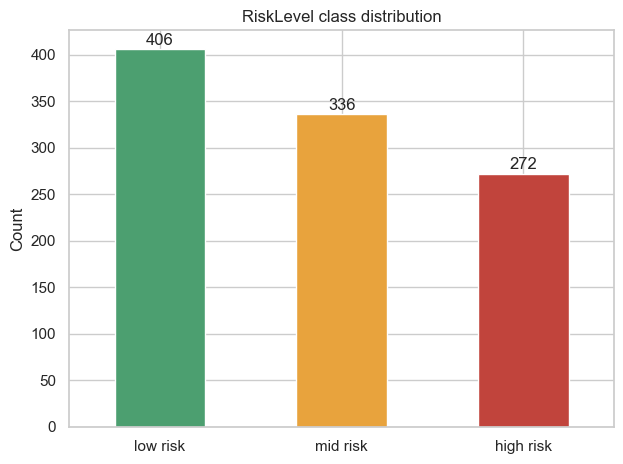

RiskLevel
low risk     0.400394
mid risk     0.331361
high risk    0.268245
Name: count, dtype: float64

In [4]:
counts = df[TARGET].value_counts().reindex(RISK_ORDER)
ax = counts.plot(kind="bar", color=["#4C9F70", "#E8A33D", "#C1443C"])
ax.set_title("RiskLevel class distribution")
ax.set_xlabel("")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
for i, v in enumerate(counts):
    ax.text(i, v + 5, str(v), ha="center")
plt.tight_layout()
plt.show()

counts / counts.sum()

Classes are moderately imbalanced (`high risk` is the smallest at ~27%) but not severely so — no resampling is applied, but this motivates looking at per-class recall (not just accuracy) in the evaluation section, since missing a true `high risk` case is the costliest error.

## 4. Feature distributions by risk level

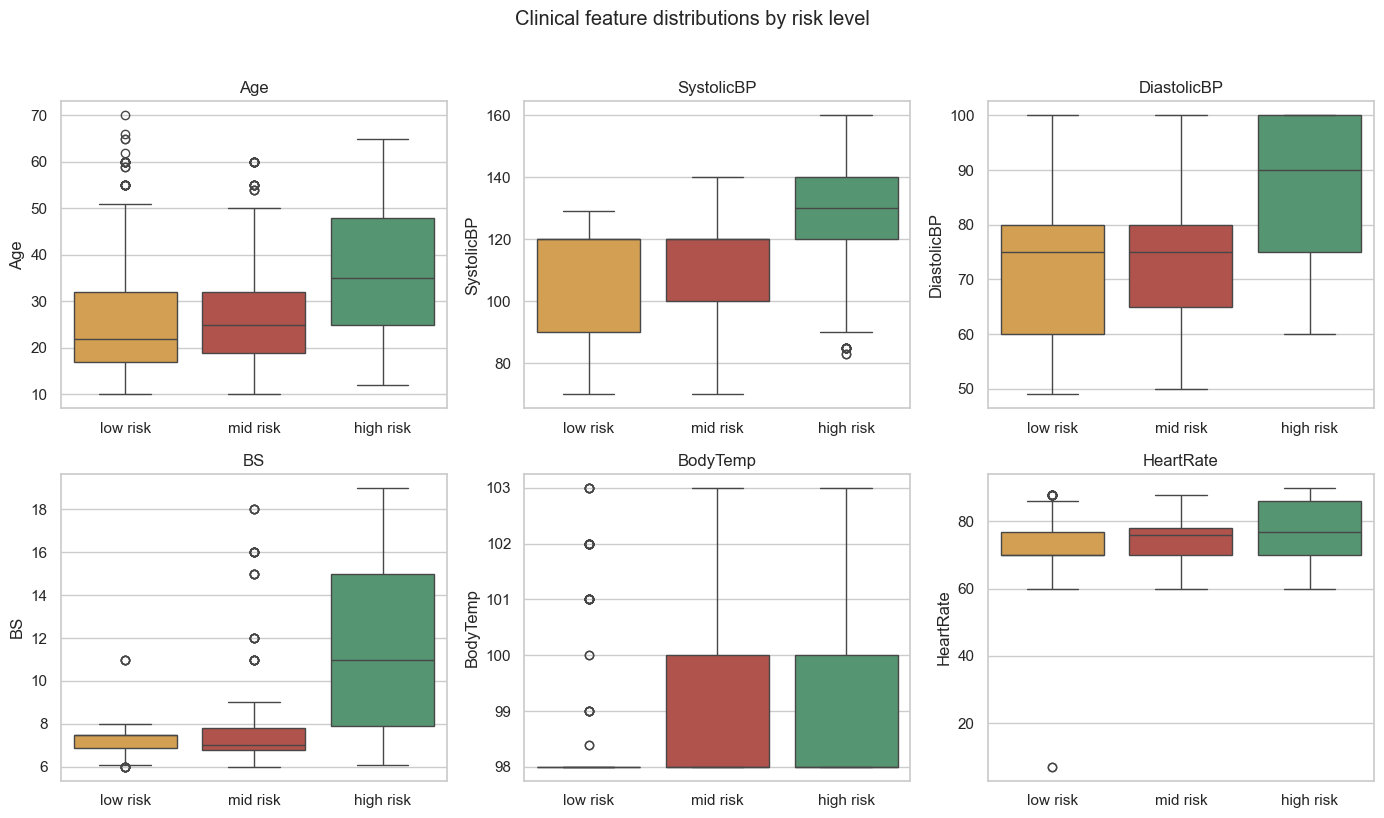

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feature in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=df, x=TARGET, y=feature, order=RISK_ORDER, ax=ax, hue=TARGET,
                palette=["#4C9F70", "#E8A33D", "#C1443C"], legend=False)
    ax.set_title(feature)
    ax.set_xlabel("")
fig.suptitle("Clinical feature distributions by risk level", y=1.02)
plt.tight_layout()
plt.show()

Blood sugar (`BS`) and blood pressure (`SystolicBP`, `DiastolicBP`) show the clearest separation across risk levels, which is clinically expected — these are the features a model should lean on most. `BodyTemp` and `HeartRate` show far more overlap between classes, so they should contribute less.

## 5. Feature correlation

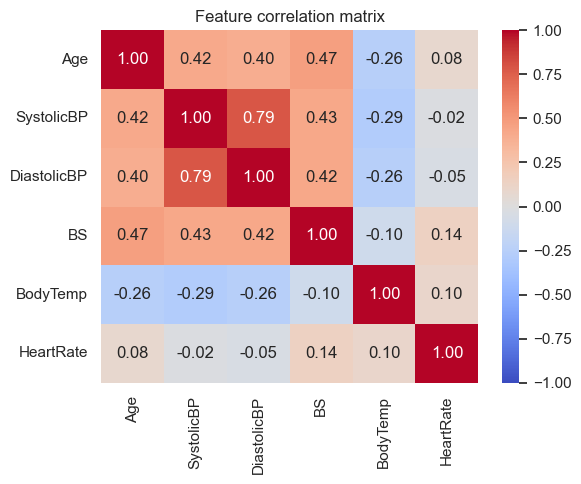

In [6]:
corr = df[FEATURES].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

`SystolicBP` and `DiastolicBP` are strongly correlated with each other (as expected physiologically), but no pair is so collinear that it would break a tree-based model — Random Forests are robust to this kind of redundancy anyway.

## 6. Train the model

Reuses `train()` from `src/task1_risk_classifier.py`: an 80/20 stratified train/test split (`random_state=42`) and a `RandomForestClassifier` (300 trees).

In [7]:
model, results = train(df)
model

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 7. Evaluation

In [8]:
report_df = pd.DataFrame(results["report"]).T
report_df

,precision,recall,f1-score,support
high risk,0.962963,0.945455,0.954128,55.000000
low risk,0.878378,0.802469,0.838710,81.000000
mid risk,0.760000,0.850746,0.802817,67.000000
accuracy,0.857143,0.857143,0.857143,0.857143
macro avg,0.867114,0.866223,0.865218,203.000000
weighted avg,0.862225,0.857143,0.858134,203.000000


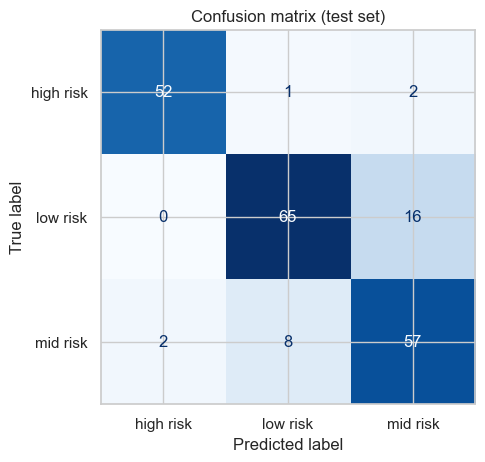

In [9]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=results["confusion_matrix"], display_labels=results["labels"]
)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion matrix (test set)")
plt.tight_layout()
plt.show()

Recall on `high risk` (the costliest class to miss) is the number to watch here — see the classification report above for the exact value on this run.

## 8. Feature importance

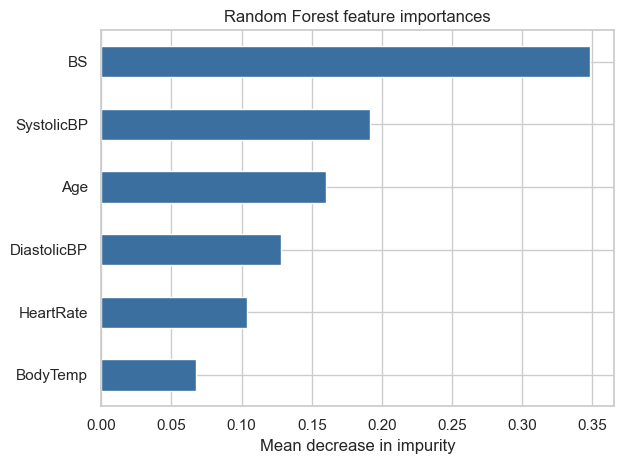

In [10]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
ax = importances.plot(kind="barh", color="#3B6FA0")
ax.set_title("Random Forest feature importances")
ax.set_xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

## 9. Summary & limitations

- Blood sugar and blood pressure readings drive most of the model's predictive signal, consistent with the boxplots in Section 4 and clinical expectations.
- The model is a screening aid, not a diagnostic tool, and was trained on data from health facilities in Bangladesh — performance on a Kenyan population is not yet validated (see Task 2/3 in `PLAN.md`).
- `high risk` recall matters more than overall accuracy for this use case; see the confusion matrix and classification report above.
- Fairness/calibration across age groups is audited separately in Task 3, using the model artifact saved by `src/task1_risk_classifier.py`.